<a href="https://colab.research.google.com/github/Rahul-Mehta555/PowerBI/blob/main/EDA_Rahul%20Mehta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration and Preprocessing

In [83]:
# Import necessary libraries
from numpy._core.defchararray import count
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 1. Import the dataset and display the first 10 rows. Also print the shape of the dataset.

In [84]:
df = pd.read_excel("EDA.xlsm")
print("---------------------First 10 Rows-----------------------")
print(df.head(10))
print("---------------------Shapes-------------------------------")
print(df.shape)

---------------------First 10 Rows-----------------------
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH    SALES  ORDERDATE  \
0        10107               30      95.70  2871.00 2018-02-24   
1        10121               34      81.35  2765.90 2018-05-07   
2        10134               41      94.74  3884.34 2018-07-01   
3        10145               45      83.26  3746.70 2018-08-25   
4        10168               36      96.66  3479.76 2018-10-28   
5        10180               29      86.13  2497.77 2018-11-11   
6        10188               48     114.84  5512.32 2018-11-18   
7        10211               41     114.84  4708.44 2019-01-15   
8        10223               37     107.18  3965.66 2019-02-20   
9        10237               23     101.44  2333.12 2019-04-05   

   DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0                   828  Shipped  Motorcycles    95    S10_1678   
1                   757  Shipped  Motorcycles    95    S10_1678   
2             

### 2. Check the data types of all columns.

In [85]:
print("--------------------Data Types-----------------------------")
print(df.dtypes)

--------------------Data Types-----------------------------
ORDERNUMBER                      int64
QUANTITYORDERED                  int64
PRICEEACH                      float64
SALES                          float64
ORDERDATE               datetime64[ns]
DAYS_SINCE_LASTORDER             int64
STATUS                          object
PRODUCTLINE                     object
MSRP                             int64
PRODUCTCODE                     object
CUSTOMERNAME                    object
ADDRESSLINE1                    object
CITY                            object
POSTALCODE                      object
COUNTRY                         object
CONTACTLASTNAME                 object
CONTACTFIRSTNAME                object
DEALSIZE                        object
dtype: object


### 3. Check for any duplicate records and delete them.

In [86]:
print("------------------Duplicates-------------------------------")
# Display duplicate rows (if any) before dropping
df[df.duplicated(["ORDERNUMBER","PRODUCTCODE","CUSTOMERNAME"], keep=False)]
print("------------------Delete duplicates-------------------------")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

------------------Duplicates-------------------------------
------------------Delete duplicates-------------------------
Shape after dropping duplicates: (2747, 18)


### 4. Check for the outliers in all numerical variables with IQR method.

In [87]:
print("----------------Outliers using IQR---------------------------")

Q1QTY = df["QUANTITYORDERED"].quantile(0.25)
Q3QTY = df["QUANTITYORDERED"].quantile(0.75)
IQRQTY = Q3QTY - Q1QTY
lower_bound = Q1QTY - 1.5 * IQRQTY
upper_bound = Q3QTY + 1.5 * IQRQTY
print("QUANTITYORDERED - Lower Bound:", lower_bound)
print("QUANTITYORDERED - Upper Bound:", upper_bound)

Q1 = df["PRICEEACH"].quantile(0.25)
Q3 = df["PRICEEACH"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("PRICEEACH - Lower Bound:", lower_bound)
print("PRICEEACH - Upper Bound:", upper_bound)

Q1 = df["SALES"].quantile(0.25)
Q3 = df["SALES"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("SALES - Lower Bound:", lower_bound)
print("SALES - Upper Bound:", upper_bound)

Q1 = df["MSRP"].quantile(0.25)
Q3 = df["MSRP"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("MSRP - Lower Bound:", lower_bound)
print("MSRP - Upper Bound:", upper_bound)

----------------Outliers using IQR---------------------------
QUANTITYORDERED - Lower Bound: 3.0
QUANTITYORDERED - Upper Bound: 67.0
PRICEEACH - Lower Bound: -18.78749999999998
PRICEEACH - Upper Bound: 214.6325
SALES - Lower Bound: -1243.7674999999995
SALES - Upper Bound: 7951.212499999999
MSRP - Lower Bound: -16.0
MSRP - Upper Bound: 208.0


### 5. Find the total number of unique customers and unique countries.

In [88]:
print("Total unique customers:" + str(df["CUSTOMERNAME"].nunique()))
print("Total unique countries:" + str(df["COUNTRY"].nunique()))

Total unique customers:89
Total unique countries:19


### 6. Convert ORDERDATE into a datetime format. Extract Year and Month as new columns.

In [89]:
# Convert ORDERDATE to datetime
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Extract Year and Month
df["Year"] = df["ORDERDATE"].dt.year
df["Month"] = df["ORDERDATE"].dt.month
print("ORDERDATE converted and Year/Month extracted.")
print(df[['ORDERDATE', 'Year', 'Month']].head())

ORDERDATE converted and Year/Month extracted.
   ORDERDATE  Year  Month
0 2018-02-24  2018      2
1 2018-05-07  2018      5
2 2018-07-01  2018      7
3 2018-08-25  2018      8
4 2018-10-28  2018     10


### 7. Create a visualization showing monthly sales trend over time.

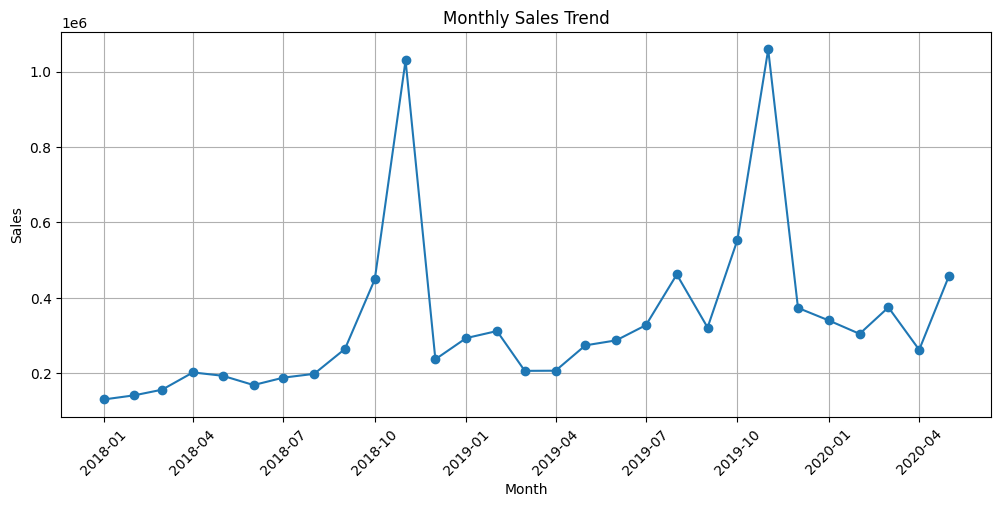

In [90]:
# Group sales by month
monthly_sales = df.groupby(
    df["ORDERDATE"].dt.to_period("M")
)["SALES"].sum()

# Convert Period to datetime for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 8. Find the total sales by country and identify the top 3 countries by sales.

In [91]:
sales_by_country =df.groupby(df["COUNTRY"])["SALES"].sum()
sales_by_country.sort_values(ascending=False, inplace=True)
print("Sales By Country (Top 3)")
print(sales_by_country.head(3))

Sales By Country (Top 3)
COUNTRY
USA       3355575.69
Spain     1215686.92
France    1110916.52
Name: SALES, dtype: float64


### 9. Calculate the average order value (SALES) for each DEALSIZE. Which deal size contributes the most revenue?
#### a. Identify and count items where the selling price is higher than MSRP.

In [92]:
order_by_dealsize = df.groupby(df["DEALSIZE"])["SALES"].mean()
order_by_dealsize.sort_values(ascending=False, inplace=True)
print("Average Sales By Deal Size")
print(order_by_dealsize.head(3))

print("\nProducts count having Price is more than MSRP : " + str((df["PRICEEACH"] > df["MSRP"]).sum()))

Average Sales By Deal Size
DEALSIZE
Large     8282.607895
Medium    4396.761653
Small     2062.627480
Name: SALES, dtype: float64

Products count having Price is more than MSRP : 1398


### 10. Bar chart of total sales by product line

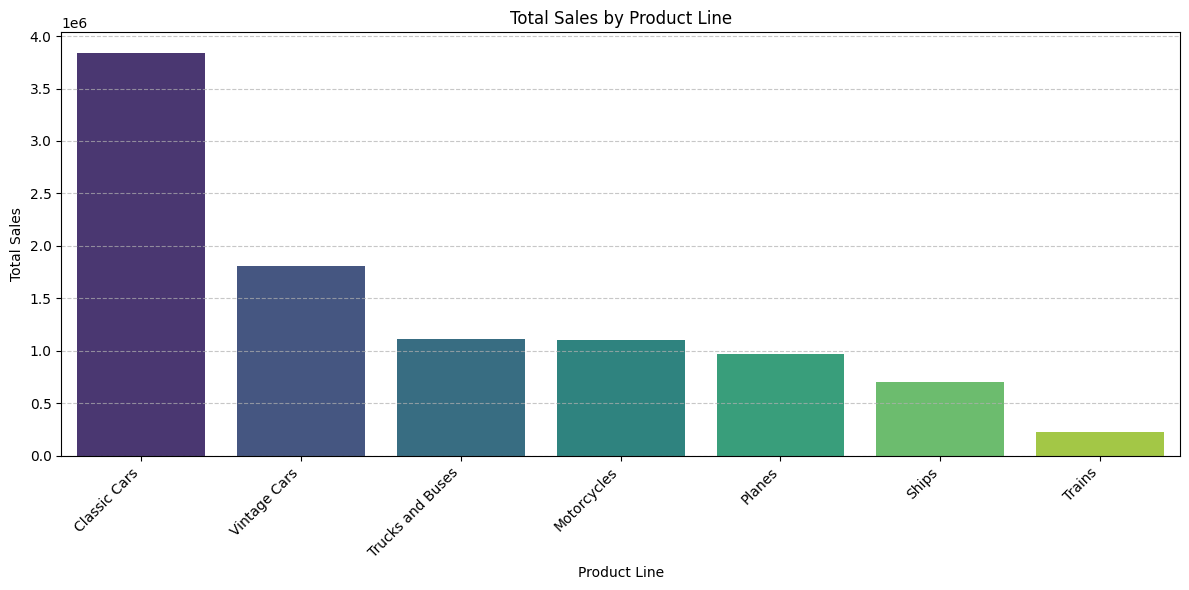

In [93]:
sales_by_productline = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_productline.index, y=sales_by_productline.values, hue=sales_by_productline.index, palette='viridis', legend=False)
plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 11. Find the relationship between QUANTITYORDERED, PRICEEACH, SALES. Create a correlation matrix and visualize it using a heatmap.

Correlation Matrix:
                 QUANTITYORDERED  PRICEEACH     SALES
QUANTITYORDERED         1.000000   0.010161  0.553359
PRICEEACH               0.010161   1.000000  0.808287
SALES                   0.553359   0.808287  1.000000


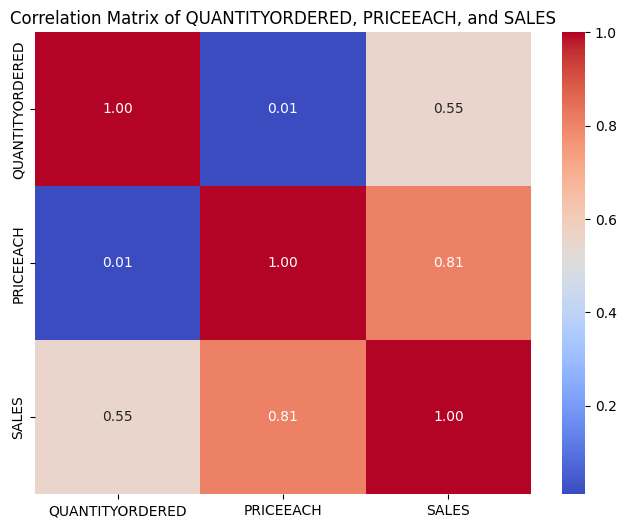

In [94]:
# Select the relevant numerical columns
selected_columns = ['QUANTITYORDERED', 'PRICEEACH', 'SALES']
correlation_matrix = df[selected_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of QUANTITYORDERED, PRICEEACH, and SALES')
plt.show()

### 12.	Find customers whose last order was more than the average days using DAYS_SINCE_LASTORDER and print customer name and days since last order.


In [95]:
Avg_days = df["DAYS_SINCE_LASTORDER"].mean()
print("Average Days Since Last Order:", Avg_days)
print(df[df["DAYS_SINCE_LASTORDER"] > Avg_days][["CUSTOMERNAME","DAYS_SINCE_LASTORDER"]])


Average Days Since Last Order: 1757.085911903895
                      CUSTOMERNAME  DAYS_SINCE_LASTORDER
922             Baane Mini Imports                  1776
947       Danish Wholesale Imports                  1788
972          Euro Shopping Channel                  1824
973   Motor Mint Distributors Inc.                  1787
974      La Corne D'abondance, Co.                  1766
...                            ...                   ...
2742         Euro Shopping Channel                  2924
2743       Oulu Toy Supplies, Inc.                  2865
2744         Euro Shopping Channel                  2836
2745                  Alpha Cognac                  2810
2746             Gifts4AllAges.com                  2772

[1379 rows x 2 columns]


#

## 13. Identify customers who have placed more than one order. Print customer name and number of orders.

In [102]:
customer_order_counts = df.groupby("CUSTOMERNAME").size()
customers_multiple_orders = customer_order_counts[customer_order_counts > 1]

print("Customers who have placed more than one order with their order counts:")
print(customers_multiple_orders)

Customers who have placed more than one order with their order counts:
CUSTOMERNAME
AV Stores, Co.                 51
Alpha Cognac                   20
Amica Models & Co.             26
Anna's Decorations, Ltd        46
Atelier graphique               7
                               ..
Vida Sport, Ltd                31
Vitachrome Inc.                25
Volvo Model Replicas, Co       19
West Coast Collectables Co.    13
giftsbymail.co.uk              26
Length: 89, dtype: int64


## 14.	Check the missing records in each column.

In [97]:
df.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
SALES,0
ORDERDATE,0
DAYS_SINCE_LASTORDER,0
STATUS,0
PRODUCTLINE,0
MSRP,0
PRODUCTCODE,0


## 15. Create 2 Dataframes – 1 for numerical and 1 for categorical using pandas.

In [98]:
df_numerical = df.select_dtypes(include="number")
df_categorical = df.select_dtypes(include="object")
print("Numerical Dataframe:")
print(df_numerical.head())
print("\nCategorical Dataframe:")
print(df_categorical.head())

Numerical Dataframe:
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH    SALES  DAYS_SINCE_LASTORDER  \
0        10107               30      95.70  2871.00                   828   
1        10121               34      81.35  2765.90                   757   
2        10134               41      94.74  3884.34                   703   
3        10145               45      83.26  3746.70                   649   
4        10168               36      96.66  3479.76                   586   

   MSRP  Year  Month  
0    95  2018      2  
1    95  2018      5  
2    95  2018      7  
3    95  2018      8  
4    95  2018     10  

Categorical Dataframe:
    STATUS  PRODUCTLINE PRODUCTCODE          CUSTOMERNAME  \
0  Shipped  Motorcycles    S10_1678     Land of Toys Inc.   
1  Shipped  Motorcycles    S10_1678    Reims Collectables   
2  Shipped  Motorcycles    S10_1678       Lyon Souveniers   
3  Shipped  Motorcycles    S10_1678     Toys4GrownUps.com   
4  Shipped  Motorcycles    S10_1678  Technics Sto

## 16.Rename the ORDERNUMBER as order_number and QUANTITYORDERED as qty_ordered.

In [99]:
df.rename(columns={"ORDERNUMBER":"order_number"}, inplace=True)
df.rename(columns={"QUANTITYORDERED":"qty_ordered"}, inplace=True)
df

,order_number,qty_ordered,PRICEEACH,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,Year,Month
0,10107,30,95.70,2871.00,2018-02-24,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small,2018,2
1,10121,34,81.35,2765.90,2018-05-07,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small,2018,5
2,10134,41,94.74,3884.34,2018-07-01,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium,2018,7
3,10145,45,83.26,3746.70,2018-08-25,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium,2018,8
4,10168,36,96.66,3479.76,2018-10-28,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium,2018,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,10350,20,112.22,2244.40,2019-12-02,2924,Shipped,Ships,54,S72_3212,Euro Shopping Channel,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small,2019,12
2743,10373,29,137.19,3978.51,2020-01-31,2865,Shipped,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",Torikatu 38,Oulu,90110,Finland,Koskitalo,Pirkko,Medium,2020,1
2744,10386,43,125.99,5417.57,2020-03-01,2836,Resolved,Ships,54,S72_3212,Euro Shopping Channel,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium,2020,3
2745,10397,34,62.24,2116.16,2020-03-28,2810,Shipped,Ships,54,S72_3212,Alpha Cognac,1 rue Alsace-Lorraine,Toulouse,31000,France,Roulet,Annette,Small,2020,3


##17. For the numerical dataframe created in Q16, perform the feature scaling (using standard scaler) to bring all variables on same scale.

In [100]:
df_numerical.drop(columns=["ORDERNUMBER", "Year", "Month"], inplace=True)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=df_numerical.columns
)

print(df_numerical_scaled.head())

   QUANTITYORDERED  PRICEEACH     SALES  DAYS_SINCE_LASTORDER     MSRP
0        -0.522831  -0.128440 -0.370956             -1.134233 -0.14191
1        -0.113010  -0.469823 -0.428119             -1.220910 -0.14191
2         0.604176  -0.151278  0.180185             -1.286834 -0.14191
3         1.013997  -0.424384  0.105325             -1.352757 -0.14191
4         0.091900  -0.105602 -0.039860             -1.429668 -0.14191


## 18.	Check for the skewness in all numerical variables and tag them as low skewed, moderately skewed and highly skewed.

In [101]:
skewness = df_numerical_scaled.skew()
for column, value in skewness.items():
    if abs(value) <= 0.5:
        print(column, "-> Low skew")
    elif abs(value) <= 1:
        print(column, "-> Moderate skew")
    else:
        print(column, "-> High skew")

QUANTITYORDERED -> Low skew
PRICEEACH -> Moderate skew
SALES -> High skew
DAYS_SINCE_LASTORDER -> Low skew
MSRP -> Moderate skew


## 19. For highly skewed variables, perform the transformation techniques and make the less/moderately skewed.

In [103]:
# Apply transformation to the highly skewed 'SALES' variable in df_numerical
df_numerical["SALES"] = np.log1p(df_numerical["SALES"])

# Re-scale the numerical DataFrame after transformation to ensure all variables are on the same scale again
# and reflect the transformation.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=df_numerical.columns
)

print("df_numerical['SALES'] after log1p transformation (head):")
print(df_numerical["SALES"].head())

print("\nSkewness after transformation and re-scaling:")
skewness = df_numerical_scaled.skew()
for column, value in skewness.items():
    if abs(value) <= 0.5:
        print(column, "-> Low skew")
    elif abs(value) <= 1:
        print(column, "-> Moderate skew")
    else:
        print(column, "-> High skew")

print("\nHead of df_numerical_scaled after re-scaling:")
print(df_numerical_scaled.head())

df_numerical['SALES'] after log1p transformation (head):
0    7.962764
1    7.925483
2    8.264966
3    8.228898
4    8.155006
Name: SALES, dtype: float64

Skewness after transformation and re-scaling:
QUANTITYORDERED -> Low skew
PRICEEACH -> Moderate skew
SALES -> Low skew
DAYS_SINCE_LASTORDER -> Low skew
MSRP -> Moderate skew

Head of df_numerical_scaled after re-scaling:
   QUANTITYORDERED  PRICEEACH     SALES  DAYS_SINCE_LASTORDER     MSRP
0        -0.522831  -0.128440 -0.158793             -1.134233 -0.14191
1        -0.113010  -0.469823 -0.230360             -1.220910 -0.14191
2         0.604176  -0.151278  0.421336             -1.286834 -0.14191
3         1.013997  -0.424384  0.352097             -1.352757 -0.14191
4         0.091900  -0.105602  0.210249             -1.429668 -0.14191
